<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%204/18_PINN_Solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook for MSE 510/420 course
- Originally from: https://github.com/janblechschmidt/PDEsByNNs
- refactored by Sergei V. Kalinin

# Using physics informed neural networks (PINNs) to solve parabolic PDEs

In this notebook, we illustrate physics informed neural networks (PINNs) to solve partial differential equations (PDEs) as proposed in

- Maziar Raissi, Paris Perdikaris, George Em Karniadakis. *Physics Informed Deep Learning (Part I): Data-driven Solutions of Nonlinear Partial Differential Equations*. [arXiv 1711.10561](https://arxiv.org/abs/1711.10561)
- Maziar Raissi, Paris Perdikaris, George Em Karniadakis. *Physics Informed Deep Learning (Part II): Data-driven Discovery of Nonlinear Partial Differential Equations*. [arXiv 1711.10566](https://arxiv.org/abs/1711.10566)
- Maziar Raissi, Paris Perdikaris, George Em Karniadakis. *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations*. J. Comp. Phys. 378 pp. 686-707 [DOI: 10.1016/j.jcp.2018.10.045](https://www.sciencedirect.com/science/article/pii/S0021999118307125)

This notebook is partially based on another implementation of the PINN approach published on [GitHub by pierremtb](https://github.com/pierremtb/PINNs-TF2.0) as well as the original code, see [Maziar Raissi on GitHub](https://github.com/maziarraissi/PINNs).

<a href="https://colab.research.google.com/github/janblechschmidt/PDEsByNNs/blob/main/PINN_Solver.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Introduction

We describe the PINN approach for approximating the solution $u:[0,T] \times \mathcal{D} \to \mathbb{R}$ of an evolution equation

$$
\begin{align}
    \partial_t u (t,x) + \mathcal{N}[u](t,x) &= 0, && (t,x) \in (0,T] \times \mathcal{D},\\
    u(0,x) &= u_0(x) \quad && x \in \mathcal{D},
\end{align}
$$

where $\mathcal{N}$ is a nonlinear differential operator acting on $u$,
$\mathcal{D} \subset \mathbb{R}^d$ a bounded domain,
$T$ denotes the final time and
$u_0: \mathcal{D} \to \mathbb{R}$ the prescribed initial data.
Although the methodology allows for different types of boundary conditions, we restrict our discussion to the inhomogeneous Dirichlet case and prescribe

$$
\begin{align}
        \hspace{7em} u(t,x) &= u_b(t,x)  && \quad (t,x) \in (0,T] \times \partial \mathcal{D},
\end{align}
$$

where $\partial \mathcal{D}$ denotes the boundary of the domain $\mathcal{D}$ and $u_b: (0,T] \times \partial \mathcal{D} \to \mathbb{R}$ the given boundary data.

## Methodology

The method constructs a neural network approximation

$$
u_\theta(t,x) \approx u(t,x)
$$

of the solution of nonlinear PDE, where $u_\theta :[0,T] \times \mathcal{D} \to \mathbb{R}$ denotes a function realized by a neural network with parameters $\theta$.

The continuous time approach for the parabolic PDE as described in ([Raissi et al., 2017 (Part I)](https://arxiv.org/abs/1711.10561)) is based on the (strong) residual of a given neural network approximation $u_\theta \colon [0,T] \times \mathcal{D} \to \mathbb{R} $ of the solution $u$, i.e.,

$$
\begin{align}
    r_\theta (t,x) := \partial_t u_\theta (t,x) + \mathcal{N}[u_\theta] (t,x).
\end{align}
$$

To incorporate this PDE residual $r_\theta$ into a loss function to be minimized, PINNs require a further differentiation to evaluate the differential operators $\partial_t u_\theta$ and $\mathcal{N}[u_\theta]$.
Thus the PINN term $r_\theta$ shares the same parameters as the original network $u_\theta(t,x)$, but respects the underlying "physics" of the nonlinear PDE.
Both types of derivatives can be easily determined through automatic differentiation with current state-of-the-art machine learning libraries, e.g., TensorFlow or PyTorch.

The PINN approach for the solution of the initial and boundary value problem now proceeds by minimization of the loss functional

$$
\begin{align}
    \phi_\theta(X) := \phi_\theta^r(X^r) + \phi_\theta^0(X^0) + \phi_\theta^b(X^b),
\end{align}
$$

where $X$ denotes the collection of training data and the loss function $\phi_\theta$ contains the following terms:

  - the mean squared residual
$$
  \begin{align*}
   \phi_\theta^r(X^r) := \frac{1}{N_r}\sum_{i=1}^{N_r} \left|r_\theta\left(t_i^r, x_i^r\right)\right|^2
\end{align*}
$$
in a number of collocation points $X^r:=\{(t_i^r, x_i^r)\}_{i=1}^{N_r} \subset (0,T] \times \mathcal{D}$, where $r_\theta$ is the physics-informed neural network,
  - the mean squared misfit with respect to the initial and boundary conditions
$$
    \begin{align*}
   \phi_\theta^0(X^0)
   :=
   \frac{1}{N_0}
   \sum_{i=1}^{N_0} \left|u_\theta\left(t_i^0, x_i^0\right) - u_0\left(x_i^0\right)\right|^2
   \quad \text{ and } \quad
   \phi_\theta^b(X^b)
   :=
   \frac{1}{N_b}
   \sum_{i=1}^{N_b} \left|u_\theta\left(t_i^b, x_i^b\right) - u_b\left(t_i^b, x_i^b\right)\right|^2
    \end{align*}
$$
in a number of points $X^0:=\{(t^0_i,x^0_i)\}_{i=1}^{N_0} \subset \{0\} \times \mathcal{D}$ and $X^b:=\{(t^b_i,x^b_i)\}_{i=1}^{N_b} \subset (0,T] \times \partial \mathcal{D}$, where $u_\theta$ is the neural network approximation of the solution $u\colon[0,T] \times \mathcal{D} \to \mathbb{R}$.

Note that the training data $X$ consists entirely of time-space coordinates.


## Example: Burgers equation

To illustrate the PINN approach we consider the one-dimensional Burgers equation on the spatial domain $\mathcal{D} = [-1,1]$

$$
\begin{aligned}
    \partial_t u + u \, \partial_x u - (0.01/\pi) \, \partial_{xx} u &= 0, \quad &&\quad (t,x) \in (0,1] \times (-1,1),\\
   u(0,x) &= - \sin(\pi \, x),                 \quad &&\quad x \in [-1,1],\\
   u(t,-1) = u(t,1) &= 0,                      \quad &&\quad t \in (0,1].
\end{aligned}
$$

This PDE arises in various disciplines such as traffic flow, fluid mechanics and gas dynamics, and can be derived from the Navier-Stokes equations, see
([Basdevant et al., 1986](https://www.researchgate.net/publication/222935980_Spectral_and_finite_difference_solutions_of_Burgers_equation)).

In [1]:
#!pip install keras==2.14.0 tensorflow==2.14.0

### 1. Import necessary packages and set problem specific data
This code runs with TensorFlow version `2.3.0`.
The implementation relies mainly on the scientific computing library [NumPy](https://numpy.org/doc/stable/user/whatisnumpy.html) and the machine learning library [TensorFlow](https://www.tensorflow.org/).

All computations were performed on an Intel i7 CPU (8th Gen) with 16 GByte DDR3 RAM (2133 MHz) within a couple of minutes.

In [2]:
# Core setup for 1D viscous Burgers' equation (refactored)

from dataclasses import dataclass

import numpy as np
import tensorflow as tf


# -----------------------------------------------------------------------------
# Global numeric configuration
# -----------------------------------------------------------------------------
DTYPE = tf.float32
tf.keras.backend.set_floatx(DTYPE.name)


# -----------------------------------------------------------------------------
# PDE configuration
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class BurgersConfig:
    dtype: tf.dtypes.DType = DTYPE
    pi_value: float = np.pi
    nu_value: float = np.pi**-1 * 0.01  # viscosity = 0.01 / pi

    @property
    def pi(self) -> tf.Tensor:
        return tf.constant(self.pi_value, dtype=self.dtype)

    @property
    def viscosity(self) -> tf.Tensor:
        return tf.constant(self.nu_value, dtype=self.dtype)


CFG = BurgersConfig()


# -----------------------------------------------------------------------------
# Problem definition
# -----------------------------------------------------------------------------
def initial_condition(x: tf.Tensor, cfg: BurgersConfig = CFG) -> tf.Tensor:
    """
    Initial condition:
        u(0, x) = -sin(pi x)

    Args:
        x: Tensor of shape (N, 1) or compatible.
        cfg: Burgers equation configuration.

    Returns:
        Tensor with the same shape as x.
    """
    x = tf.cast(x, cfg.dtype)
    return -tf.sin(cfg.pi * x)


def boundary_condition(t: tf.Tensor, x: tf.Tensor, cfg: BurgersConfig = CFG) -> tf.Tensor:
    """
    Homogeneous Dirichlet boundary condition:
        u(t, x_boundary) = 0

    Args:
        t: Tensor of time coordinates (unused here, kept for API consistency).
        x: Tensor of boundary spatial coordinates.
        cfg: Burgers equation configuration.

    Returns:
        Zero tensor of shape compatible with x.
    """
    del t  # boundary is time-independent, but keep signature consistent
    x = tf.cast(x, cfg.dtype)
    return tf.zeros_like(x, dtype=cfg.dtype)


def burgers_residual(
    t: tf.Tensor,
    x: tf.Tensor,
    u: tf.Tensor,
    u_t: tf.Tensor,
    u_x: tf.Tensor,
    u_xx: tf.Tensor,
    cfg: BurgersConfig = CFG,
) -> tf.Tensor:
    """
    PDE residual for 1D viscous Burgers' equation:
        u_t + u * u_x - nu * u_xx = 0

    Args:
        t: Time coordinates (unused in the algebraic residual, kept for API consistency).
        x: Spatial coordinates (unused in the algebraic residual, kept for API consistency).
        u: Predicted field.
        u_t: Time derivative of u.
        u_x: First spatial derivative of u.
        u_xx: Second spatial derivative of u.
        cfg: Burgers equation configuration.

    Returns:
        Residual tensor.
    """
    del t, x
    u = tf.cast(u, cfg.dtype)
    u_t = tf.cast(u_t, cfg.dtype)
    u_x = tf.cast(u_x, cfg.dtype)
    u_xx = tf.cast(u_xx, cfg.dtype)

    return u_t + u * u_x - cfg.viscosity * u_xx

### 2. Generate a set of collocation points

We assume that the collocation points $X_r$ as well as the points for the initial time and boundary data $X_0$ and $X_b$ are generated by random sampling from a uniform distribution.
Although uniformly distributed data are sufficient in our experiments, the authors of
([Raissi et al., 2017 (Part I)](https://arxiv.org/abs/1711.10561))
employed a space-filling Latin hypercube sampling strategy ([Stein, 1987](https://www.tandfonline.com/doi/abs/10.1080/00401706.1987.10488205)).
Our numerical experiments indicate that this strategy slightly improves the observed convergence rate, but for simplicity the code examples accompanying this paper employ uniform sampling throughout.
We choose training data of size $N_0 = N_b =50$ and $N_f=10000$.

In [3]:
# Training data generation for 1D viscous Burgers' equation (refactored)

from dataclasses import dataclass


# -----------------------------------------------------------------------------
# Sampling configuration
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class DomainConfig:
    t_min: float = 0.0
    t_max: float = 1.0
    x_min: float = -1.0
    x_max: float = 1.0
    n_initial: int = 50
    n_boundary: int = 50
    n_residual: int = 10_000
    seed: int = 0
    dtype: tf.dtypes.DType = DTYPE

    @property
    def lower_bound(self) -> tf.Tensor:
        return tf.constant([self.t_min, self.x_min], dtype=self.dtype)

    @property
    def upper_bound(self) -> tf.Tensor:
        return tf.constant([self.t_max, self.x_max], dtype=self.dtype)


DOMAIN = DomainConfig()


# -----------------------------------------------------------------------------
# Sampling utilities
# -----------------------------------------------------------------------------
def make_rng(seed: int) -> tf.random.Generator:
    return tf.random.Generator.from_seed(seed)


def sample_uniform(
    rng: tf.random.Generator,
    shape: tuple[int, int],
    minval: float,
    maxval: float,
    dtype: tf.dtypes.DType = DTYPE,
) -> tf.Tensor:
    return rng.uniform(shape=shape, minval=minval, maxval=maxval, dtype=dtype)


def sample_boundary_points(
    rng: tf.random.Generator,
    n_points: int,
    x_min: float,
    x_max: float,
    dtype: tf.dtypes.DType = DTYPE,
) -> tf.Tensor:
    """
    Sample boundary x-values from {x_min, x_max} with equal probability.
    """
    selector = rng.uniform(shape=(n_points, 1), minval=0.0, maxval=1.0, dtype=dtype)
    x_min_tensor = tf.constant(x_min, dtype=dtype)
    x_max_tensor = tf.constant(x_max, dtype=dtype)
    return tf.where(selector < 0.5, x_min_tensor, x_max_tensor)


# -----------------------------------------------------------------------------
# Generate training data
# -----------------------------------------------------------------------------
def generate_training_data(
    domain: DomainConfig = DOMAIN,
    pde_cfg: BurgersConfig = CFG,
):
    rng = make_rng(domain.seed)

    lb = domain.lower_bound
    ub = domain.upper_bound

    # Initial-condition data: t = t_min, x ~ U[x_min, x_max]
    t_0 = tf.fill([domain.n_initial, 1], tf.cast(domain.t_min, domain.dtype))
    x_0 = sample_uniform(
        rng,
        shape=(domain.n_initial, 1),
        minval=domain.x_min,
        maxval=domain.x_max,
        dtype=domain.dtype,
    )
    X_0 = tf.concat([t_0, x_0], axis=1)
    u_0 = initial_condition(x_0, cfg=pde_cfg)

    # Boundary-condition data: t ~ U[t_min, t_max], x in {x_min, x_max}
    t_b = sample_uniform(
        rng,
        shape=(domain.n_boundary, 1),
        minval=domain.t_min,
        maxval=domain.t_max,
        dtype=domain.dtype,
    )
    x_b = sample_boundary_points(
        rng,
        n_points=domain.n_boundary,
        x_min=domain.x_min,
        x_max=domain.x_max,
        dtype=domain.dtype,
    )
    X_b = tf.concat([t_b, x_b], axis=1)
    u_b = boundary_condition(t_b, x_b, cfg=pde_cfg)

    # Collocation / residual points: (t, x) ~ U([t_min, t_max] x [x_min, x_max])
    t_r = sample_uniform(
        rng,
        shape=(domain.n_residual, 1),
        minval=domain.t_min,
        maxval=domain.t_max,
        dtype=domain.dtype,
    )
    x_r = sample_uniform(
        rng,
        shape=(domain.n_residual, 1),
        minval=domain.x_min,
        maxval=domain.x_max,
        dtype=domain.dtype,
    )
    X_r = tf.concat([t_r, x_r], axis=1)

    # Package outputs
    X_data = [X_0, X_b]
    u_data = [u_0, u_b]

    return {
        "lb": lb,
        "ub": ub,
        "X_0": X_0,
        "u_0": u_0,
        "X_b": X_b,
        "u_b": u_b,
        "X_r": X_r,
        "X_data": X_data,
        "u_data": u_data,
    }


# -----------------------------------------------------------------------------
# Instantiate data
# -----------------------------------------------------------------------------
data = generate_training_data(domain=DOMAIN, pde_cfg=CFG)

lb = data["lb"]
ub = data["ub"]

X_0, u_0 = data["X_0"], data["u_0"]
X_b, u_b = data["X_b"], data["u_b"]
X_r = data["X_r"]

X_data = data["X_data"]
u_data = data["u_data"]

Next, we illustrate the collocation points (red circles) and the positions where the boundary and initial conditions will be enforced (cross marks, color indicates value).

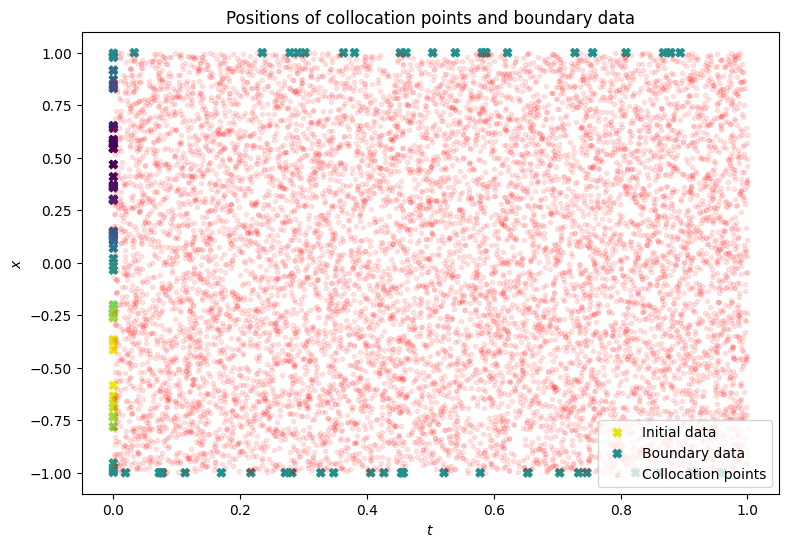

In [4]:
import matplotlib.pyplot as plt


def plot_training_points(
    X_0: tf.Tensor,
    u_0: tf.Tensor,
    X_b: tf.Tensor,
    u_b: tf.Tensor,
    X_r: tf.Tensor,
    figsize: tuple[int, int] = (9, 6),
    save_path: str | None = None,
) -> None:
    """
    Visualize initial-condition points, boundary-condition points,
    and interior collocation points in the (t, x) domain.
    """
    X_0_np = X_0.numpy()
    u_0_np = u_0.numpy().squeeze()

    X_b_np = X_b.numpy()
    u_b_np = u_b.numpy().squeeze()

    X_r_np = X_r.numpy()

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        X_0_np[:, 0],
        X_0_np[:, 1],
        c=u_0_np,
        marker="X",
        vmin=-1.0,
        vmax=1.0,
        label="Initial data",
    )

    ax.scatter(
        X_b_np[:, 0],
        X_b_np[:, 1],
        c=u_b_np,
        marker="X",
        vmin=-1.0,
        vmax=1.0,
        label="Boundary data",
    )

    ax.scatter(
        X_r_np[:, 0],
        X_r_np[:, 1],
        c="r",
        marker=".",
        alpha=0.1,
        label="Collocation points",
    )

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x$")
    ax.set_title("Positions of collocation points and boundary data")
    ax.legend()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


plot_training_points(
    X_0=X_0,
    u_0=u_0,
    X_b=X_b,
    u_b=u_b,
    X_r=X_r,
    # save_path="Xdata_Burgers.pdf",
)

### 3. Set up network architecture

In this example, adopted from
([Raissi et al., 2017 (Part I)](https://arxiv.org/abs/1711.10561)), we assume a feedforward neural network of the following structure:
- the input is scaled elementwise to lie in the interval $[-1,1]$,
- followed by 8 fully connected layers each containing 20 neurons and each followed by a hyperbolic tangent activation function,
- one fully connected output layer.

This setting results in a network with $3021$ trainable parameters (first hidden layer: $2 \cdot 20 + 20 = 60$; seven intermediate layers: each $20 \cdot 20 + 20 = 420$; output layer: $20 \cdot 1 + 1 = 21$).

In [5]:
def build_pinn(
    lower_bound: tf.Tensor,
    upper_bound: tf.Tensor,
    num_hidden_layers: int = 8,
    num_neurons_per_layer: int = 20,
    activation: str = "tanh",
    kernel_initializer: str = "glorot_normal",
    dtype: tf.dtypes.DType = DTYPE,
) -> tf.keras.Model:
    """
    Build a fully connected PINN for 1D Burgers' equation.

    Args:
        lower_bound: Tensor [t_min, x_min].
        upper_bound: Tensor [t_max, x_max].
        num_hidden_layers: Number of hidden dense layers.
        num_neurons_per_layer: Width of each hidden layer.
        activation: Activation function for hidden layers.
        kernel_initializer: Initializer for dense kernels.
        dtype: TensorFlow dtype.

    Returns:
        A tf.keras.Model mapping (t, x) -> u(t, x).
    """
    lower_bound = tf.cast(lower_bound, dtype)
    upper_bound = tf.cast(upper_bound, dtype)

    inputs = tf.keras.Input(shape=(2,), dtype=dtype, name="tx_input")

    scaled_inputs = tf.keras.layers.Lambda(
        lambda x: 2.0 * (x - lower_bound) / (upper_bound - lower_bound) - 1.0,
        name="input_scaling",
    )(inputs)

    x = scaled_inputs
    for layer_idx in range(num_hidden_layers):
        x = tf.keras.layers.Dense(
            units=num_neurons_per_layer,
            activation=activation,
            kernel_initializer=kernel_initializer,
            dtype=dtype,
            name=f"dense_{layer_idx + 1}",
        )(x)

    outputs = tf.keras.layers.Dense(
        units=1,
        activation=None,
        kernel_initializer=kernel_initializer,
        dtype=dtype,
        name="u_output",
    )(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="burgers_pinn")


model = build_pinn(
    lower_bound=lb,
    upper_bound=ub,
    num_hidden_layers=8,
    num_neurons_per_layer=20,
)

### 4. Define routines to determine loss and gradient

In the following code cell, we define a function which evaluates the residual

$$
\begin{align}
    r_\theta (t,x) := \partial_t u_\theta (t,x) + \mathcal{N}[u_\theta] (t,x).
\end{align}
$$

of the nonlinear PDE in the points $X_r = \{(t^r_i,x^r_i)\}_{i=1}^{N_r}$.
To compute the necessary partial derivatives we use the automatic differentiation capabilities of TensorFlow.

For the Burgers equation, this entails computing $\partial_t u_\theta$, $\partial_x u_\theta$ and $\partial_{xx} u_\theta$.
In TensorFlow, this is done via a `GradientTape`, see also the [documentation](https://www.tensorflow.org/api_docs/python/tf/GradientTape), which keeps track of the `watched` variables, in our case `t` and `x`, in order to compute the derivatives.

In [6]:
def compute_pde_residual(
    model: tf.keras.Model,
    X_r: tf.Tensor,
    pde_cfg: BurgersConfig = CFG,
) -> tf.Tensor:
    """
    Compute the Burgers PDE residual at collocation points.

    Args:
        model: PINN model mapping (t, x) -> u(t, x).
        X_r: Collocation points of shape (N, 2), with columns [t, x].
        pde_cfg: Burgers equation configuration.

    Returns:
        Residual tensor r(t, x) of shape (N, 1).
    """
    X_r = tf.cast(X_r, pde_cfg.dtype)

    t = X_r[:, 0:1]
    x = X_r[:, 1:2]

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        tape.watch(x)

        tx = tf.concat([t, x], axis=1)
        u = model(tx)

        u_x = tape.gradient(u, x)

    u_t = tape.gradient(u, t)
    u_xx = tape.gradient(u_x, x)

    del tape

    return burgers_residual(
        t=t,
        x=x,
        u=u,
        u_t=u_t,
        u_x=u_x,
        u_xx=u_xx,
        cfg=pde_cfg,
    )


# Backward-compatible alias, if you want to preserve the original notebook API
def get_r(model: tf.keras.Model, X_r: tf.Tensor) -> tf.Tensor:
    return compute_pde_residual(model=model, X_r=X_r, pde_cfg=CFG)

The next function computes the loss for our model

$$
\begin{align}
    \phi_\theta(X) := \phi_\theta^r(X^r) + \phi_\theta^0(X^0) + \phi_\theta^b(X^b),
\end{align}
$$

as a function of our the training data.
The collocation points are given by `X_r`, the initial and boundary data is contained in `X_data = [X_0, X_b]` and `u_data = [u_0, u_b]`.

In [7]:
def compute_data_loss(
    model: tf.keras.Model,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
    dtype: tf.dtypes.DType = DTYPE,
) -> tf.Tensor:
    """
    Compute supervised loss on initial and boundary condition data.
    """
    if len(X_data) != len(u_data):
        raise ValueError("X_data and u_data must have the same length.")

    data_loss = tf.constant(0.0, dtype=dtype)

    for inputs, targets in zip(X_data, u_data):
        inputs = tf.cast(inputs, dtype)
        targets = tf.cast(targets, dtype)

        predictions = model(inputs)
        data_loss += tf.reduce_mean(tf.square(targets - predictions))

    return data_loss


def compute_residual_loss(
    model: tf.keras.Model,
    X_r: tf.Tensor,
    pde_cfg: BurgersConfig = CFG,
) -> tf.Tensor:
    """
    Compute physics loss from the PDE residual at collocation points.
    """
    residual = compute_pde_residual(model=model, X_r=X_r, pde_cfg=pde_cfg)
    return tf.reduce_mean(tf.square(residual))


def compute_total_loss(
    model: tf.keras.Model,
    X_r: tf.Tensor,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
    pde_cfg: BurgersConfig = CFG,
    dtype: tf.dtypes.DType = DTYPE,
) -> tf.Tensor:
    """
    Compute total PINN loss:
        L = L_residual + L_data
    where L_data includes initial and boundary condition terms.
    """
    residual_loss = compute_residual_loss(model=model, X_r=X_r, pde_cfg=pde_cfg)
    data_loss = compute_data_loss(model=model, X_data=X_data, u_data=u_data, dtype=dtype)

    return residual_loss + data_loss


# Backward-compatible alias for the original notebook API
def compute_loss(
    model: tf.keras.Model,
    X_r: tf.Tensor,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
) -> tf.Tensor:
    return compute_total_loss(
        model=model,
        X_r=X_r,
        X_data=X_data,
        u_data=u_data,
        pde_cfg=CFG,
        dtype=DTYPE,
    )

The next function computes the gradient of the loss function $\phi_\theta$ with respect to the unknown variables in the model, also called `trainable_variables` in TensorFlow, i.e. $\nabla_\theta \phi_\theta$.
This is also done via a `GradientTape`, but now it keeps track of the parameters $\theta$ in our model, which can be accessed by `model.trainable_variables`.

In [8]:
def compute_gradients(
    model: tf.keras.Model,
    X_r: tf.Tensor,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
    pde_cfg: BurgersConfig = CFG,
    dtype: tf.dtypes.DType = DTYPE,
) -> tuple[tf.Tensor, list[tf.Tensor | None]]:
    """
    Compute total loss and gradients with respect to model trainable variables.

    Args:
        model: PINN model.
        X_r: Collocation points.
        X_data: List of supervised input tensors.
        u_data: List of supervised target tensors.
        pde_cfg: Burgers equation configuration.
        dtype: TensorFlow dtype.

    Returns:
        A tuple of:
            - total loss tensor
            - list of gradients aligned with model.trainable_variables
    """
    with tf.GradientTape() as tape:
        loss = compute_total_loss(
            model=model,
            X_r=X_r,
            X_data=X_data,
            u_data=u_data,
            pde_cfg=pde_cfg,
            dtype=dtype,
        )

    gradients = tape.gradient(loss, model.trainable_variables)
    return loss, gradients


# Backward-compatible alias for the original notebook API
def get_grad(
    model: tf.keras.Model,
    X_r: tf.Tensor,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
) -> tuple[tf.Tensor, list[tf.Tensor | None]]:
    return compute_gradients(
        model=model,
        X_r=X_r,
        X_data=X_data,
        u_data=u_data,
        pde_cfg=CFG,
        dtype=DTYPE,
    )

### 5. Set up optimizer and train model

Next we initialize the model, set the learning rate to the step function

$$
\delta(n) = 0.01 \, \textbf{1}_{\{n < 1000\}} + 0.001 \, \textbf{1}_{\{1000 \le n < 3000\}} + 0.0005 \, \textbf{1}_{\{3000 \le n\}}
$$

which decays in a piecewise constant fashion, and set up a `tf.keras.optimizer` to train the model.

In [9]:
# Model and optimizer initialization (refactored)

from dataclasses import dataclass


@dataclass(frozen=True)
class NetworkConfig:
    num_hidden_layers: int = 8
    num_neurons_per_layer: int = 20
    activation: str = "tanh"
    kernel_initializer: str = "glorot_normal"
    dtype: tf.dtypes.DType = DTYPE


@dataclass(frozen=True)
class OptimizerConfig:
    boundaries: tuple[int, ...] = (1000, 3000)
    values: tuple[float, ...] = (1e-2, 1e-3, 5e-4)
    optimizer_name: str = "adam"


NETWORK = NetworkConfig()
OPTIMIZER = OptimizerConfig()


def build_learning_rate_schedule(
    config: OptimizerConfig = OPTIMIZER,
) -> tf.keras.optimizers.schedules.LearningRateSchedule:
    """
    Create a piecewise-constant learning-rate schedule.
    """
    return tf.keras.optimizers.schedules.PiecewiseConstantDecay(
        boundaries=list(config.boundaries),
        values=list(config.values),
    )


def build_optimizer(
    config: OptimizerConfig = OPTIMIZER,
) -> tf.keras.optimizers.Optimizer:
    """
    Build the optimizer used for PINN training.
    """
    learning_rate_schedule = build_learning_rate_schedule(config)

    if config.optimizer_name.lower() == "adam":
        return tf.keras.optimizers.Adam(learning_rate=learning_rate_schedule)

    raise ValueError(f"Unsupported optimizer: {config.optimizer_name}")


# Initialize model u_theta
model = build_pinn(
    lower_bound=lb,
    upper_bound=ub,
    num_hidden_layers=NETWORK.num_hidden_layers,
    num_neurons_per_layer=NETWORK.num_neurons_per_layer,
    activation=NETWORK.activation,
    kernel_initializer=NETWORK.kernel_initializer,
    dtype=NETWORK.dtype,
)

# Initialize optimizer
optim = build_optimizer(OPTIMIZER)
lr = build_learning_rate_schedule(OPTIMIZER)

Train the model for $N=5000$ epochs (takes approximately 3 minutes).
Here, we set up a function `train_step()` which performs one training step.

*Note*: The `@tf.function` is a so-called `Decorator` within Python. This particular decorator redefines the function that follows, in our case `train_step`, as a TensorFlow graph which may speed up the training significantly.

In [10]:
from dataclasses import dataclass
from time import time


@dataclass(frozen=True)
class TrainingConfig:
    epochs: int = 5000
    log_every: int = 50


TRAINING = TrainingConfig()


@tf.function
def train_step(
    model: tf.keras.Model,
    optimizer: tf.keras.optimizers.Optimizer,
    X_r: tf.Tensor,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
) -> tf.Tensor:
    """
    Perform one optimization step and return the current loss.
    """
    with tf.GradientTape() as tape:
        loss = compute_total_loss(
            model=model,
            X_r=X_r,
            X_data=X_data,
            u_data=u_data,
            pde_cfg=CFG,
            dtype=DTYPE,
        )

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss


def train_model(
    model: tf.keras.Model,
    optimizer: tf.keras.optimizers.Optimizer,
    X_r: tf.Tensor,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
    config: TrainingConfig = TRAINING,
) -> list[float]:
    """
    Train the PINN and return the loss history.
    """
    history: list[float] = []

    start_time = time()

    for epoch in range(config.epochs + 1):
        loss = train_step(
            model=model,
            optimizer=optimizer,
            X_r=X_r,
            X_data=X_data,
            u_data=u_data,
        )

        loss_value = float(loss.numpy())
        history.append(loss_value)

        if epoch % config.log_every == 0:
            print(f"It {epoch:05d}: loss = {loss_value:10.8e}")

    elapsed_time = time() - start_time
    print(f"\nComputation time: {elapsed_time:.2f} seconds")

    return history


# Train the model
hist = train_model(
    model=model,
    optimizer=optim,
    X_r=X_r,
    X_data=X_data,
    u_data=u_data,
    config=TRAINING,
)

It 00000: loss = 8.99926126e-01
It 00050: loss = 1.47504523e-01
It 00100: loss = 1.13800749e-01
It 00150: loss = 9.50723216e-02
It 00200: loss = 7.58206621e-02
It 00250: loss = 5.93248159e-02
It 00300: loss = 4.32857946e-02
It 00350: loss = 1.15964562e-01
It 00400: loss = 6.67791590e-02
It 00450: loss = 7.93704614e-02
It 00500: loss = 4.54072915e-02
It 00550: loss = 3.79737645e-01
It 00600: loss = 5.24185263e-02
It 00650: loss = 3.62487510e-02
It 00700: loss = 5.82720451e-02
It 00750: loss = 5.99783845e-02
It 00800: loss = 9.98763181e-03
It 00850: loss = 1.18923753e-01
It 00900: loss = 7.50752119e-03
It 00950: loss = 7.19273463e-03
It 01000: loss = 1.94079895e-02
It 01050: loss = 1.09751513e-02
It 01100: loss = 7.89421238e-03
It 01150: loss = 6.34175120e-03
It 01200: loss = 5.32900402e-03
It 01250: loss = 4.49820189e-03
It 01300: loss = 4.01411252e-03
It 01350: loss = 3.54867009e-03
It 01400: loss = 3.24791460e-03
It 01450: loss = 2.93865800e-03
It 01500: loss = 2.69055925e-03
It 01550

### Plot solution

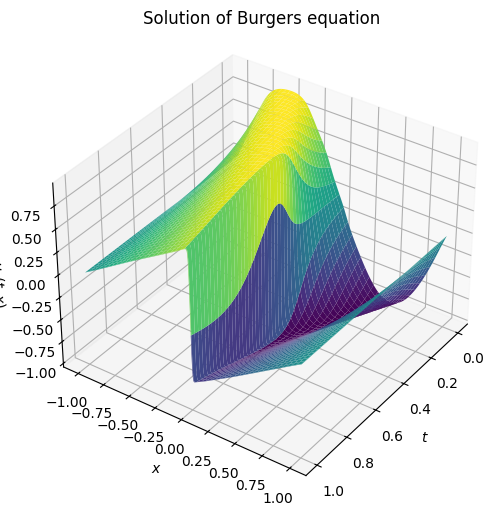

In [11]:
import matplotlib.pyplot as plt


def make_prediction_grid(
    lower_bound: tf.Tensor,
    upper_bound: tf.Tensor,
    n_points: int = 600,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Create a structured (t, x) grid over the spatiotemporal domain.

    Args:
        lower_bound: Tensor [t_min, x_min].
        upper_bound: Tensor [t_max, x_max].
        n_points: Number of intervals per axis.

    Returns:
        T: Meshgrid array for time.
        X: Meshgrid array for space.
        X_grid: Flattened coordinate array of shape ((n_points+1)^2, 2).
    """
    lb_np = lower_bound.numpy()
    ub_np = upper_bound.numpy()

    t_space = np.linspace(lb_np[0], ub_np[0], n_points + 1)
    x_space = np.linspace(lb_np[1], ub_np[1], n_points + 1)

    T, X = np.meshgrid(t_space, x_space)
    X_grid = np.column_stack([T.ravel(), X.ravel()])

    return T, X, X_grid


def predict_on_grid(
    model: tf.keras.Model,
    lower_bound: tf.Tensor,
    upper_bound: tf.Tensor,
    n_points: int = 600,
    dtype: tf.dtypes.DType = DTYPE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Evaluate the trained PINN on a structured (t, x) grid.

    Args:
        model: Trained PINN model.
        lower_bound: Tensor [t_min, x_min].
        upper_bound: Tensor [t_max, x_max].
        n_points: Number of intervals per axis.
        dtype: TensorFlow dtype.

    Returns:
        T: Meshgrid array for time.
        X: Meshgrid array for space.
        U: Predicted solution on the meshgrid.
    """
    T, X, X_grid = make_prediction_grid(
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        n_points=n_points,
    )

    u_pred = model(tf.cast(X_grid, dtype))
    U = u_pred.numpy().reshape(n_points + 1, n_points + 1)

    return T, X, U


def plot_solution_surface(
    T: np.ndarray,
    X: np.ndarray,
    U: np.ndarray,
    figsize: tuple[int, int] = (9, 6),
    elev: float = 35.0,
    azim: float = 35.0,
    cmap: str = "viridis",
    save_path: str | None = None,
) -> None:
    """
    Plot the PINN solution u(t, x) as a 3D surface.
    """
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    surface = ax.plot_surface(T, X, U, cmap=cmap)

    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x$")
    ax.set_zlabel(r"$u_\theta(t,x)$")
    ax.set_title("Solution of Burgers equation")

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


# Evaluate model on a grid
T, X, U = predict_on_grid(
    model=model,
    lower_bound=lb,
    upper_bound=ub,
    n_points=600,
    dtype=DTYPE,
)

# Plot the predicted solution
plot_solution_surface(
    T=T,
    X=X,
    U=U,
    # save_path="Burgers_Solution.pdf",
)

### Plot the evolution of loss

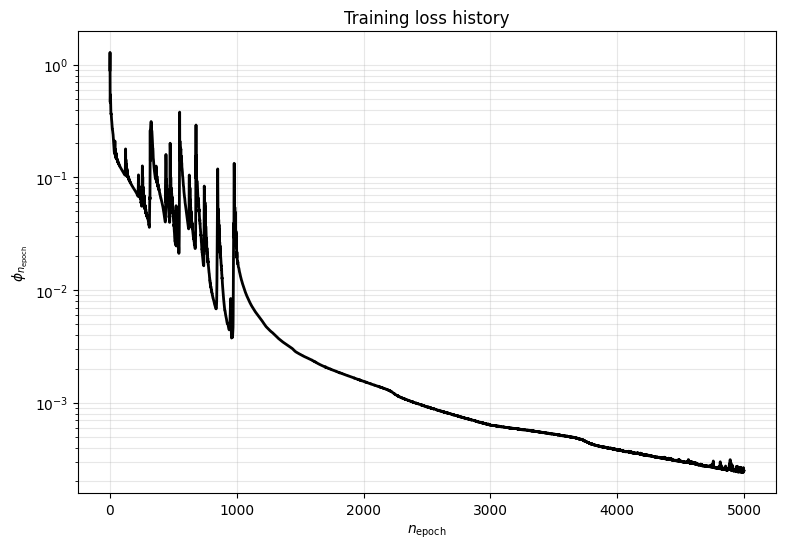

In [12]:
def plot_loss_history(
    history: list[float],
    figsize: tuple[int, int] = (9, 6),
    color: str = "k",
    linestyle: str = "-",
    save_path: str | None = None,
) -> None:
    """
    Plot the training loss history on a logarithmic y-scale.

    Args:
        history: List of scalar loss values recorded during training.
        figsize: Figure size.
        color: Line color.
        linestyle: Line style.
        save_path: Optional path for saving the figure.
    """
    fig, ax = plt.subplots(figsize=figsize)

    ax.semilogy(
        range(len(history)),
        history,
        color=color,
        linestyle=linestyle,
        linewidth=2.0,
    )

    ax.set_xlabel(r"$n_{\mathrm{epoch}}$")
    ax.set_ylabel(r"$\phi_{n_{\mathrm{epoch}}}$")
    ax.set_title("Training loss history")
    ax.grid(True, which="both", alpha=0.3)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


plot_loss_history(
    history=hist,
    # save_path="Burgers_Loss_History.pdf",
)

## Class implementation of PINNs

In this section, we implement PINNs as a class which can be used for further testing. Here, we derive the class `PINN_NeuralNet` from `tf.keras.Model`.

Required arguments are the lower bound `lb` and upper bound `ub`.

In [13]:
class BurgersPINN(tf.keras.Model):
    """
    Physics-Informed Neural Network for 1D viscous Burgers' equation.

    Maps input coordinates (t, x) to the scalar field u(t, x).
    """

    def __init__(
        self,
        lower_bound: tf.Tensor,
        upper_bound: tf.Tensor,
        output_dim: int = 1,
        num_hidden_layers: int = 8,
        num_neurons_per_layer: int = 20,
        activation: str = "tanh",
        kernel_initializer: str = "glorot_normal",
        dtype: tf.dtypes.DType = DTYPE,
        name: str = "burgers_pinn",
        **kwargs,
    ):
        super().__init__(name=name, **kwargs)

        self.output_dim = output_dim
        self.num_hidden_layers = num_hidden_layers
        self.num_neurons_per_layer = num_neurons_per_layer
        self.activation = activation
        self.kernel_initializer = kernel_initializer
        self.dtype_ = dtype

        self.lower_bound = tf.cast(lower_bound, dtype)
        self.upper_bound = tf.cast(upper_bound, dtype)

        self.input_scaling = tf.keras.layers.Lambda(
            lambda x: 2.0 * (x - self.lower_bound) / (self.upper_bound - self.lower_bound) - 1.0,
            name="input_scaling",
        )

        self.hidden_layers = [
            tf.keras.layers.Dense(
                units=num_neurons_per_layer,
                activation=activation,
                kernel_initializer=kernel_initializer,
                dtype=dtype,
                name=f"dense_{i + 1}",
            )
            for i in range(num_hidden_layers)
        ]

        self.output_layer = tf.keras.layers.Dense(
            units=output_dim,
            activation=None,
            kernel_initializer=kernel_initializer,
            dtype=dtype,
            name="output_layer",
        )

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        """
        Forward pass through the network.

        Args:
            inputs: Tensor of shape (N, 2) with columns [t, x].

        Returns:
            Tensor of shape (N, output_dim).
        """
        z = tf.cast(inputs, self.dtype_)
        z = self.input_scaling(z)

        for layer in self.hidden_layers:
            z = layer(z)

        return self.output_layer(z)


# Example usage
model = BurgersPINN(
    lower_bound=lb,
    upper_bound=ub,
    output_dim=1,
    num_hidden_layers=8,
    num_neurons_per_layer=20,
    activation="tanh",
    kernel_initializer="glorot_normal",
    dtype=DTYPE,
)

Next, we derive a class `PINNSolver` which can be used as a base class.
It possesses two methods to solve the PDE:
  1. the method `solve_with_TFoptimizer` uses a `TensorFlow` optimizer object as input, e.g., the `AdamOptimizer` above;
  2. the method `solve_with_LBFGS` resembles the LBFGS method proposed in the original paper using an LBFGS method provided by [`SciPy`](https://www.scipy.org/).

In [14]:
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
import tensorflow as tf


class PINNSolver:
    """
    Optimization wrapper for a Physics-Informed Neural Network (PINN)
    solving the 1D viscous Burgers' equation.

    This refactored version:
      - keeps PDE logic delegated to the existing helper functions
      - avoids storing split t/x tensors as mutable solver state
      - supports both TensorFlow optimizers and SciPy L-BFGS-B
      - packs/unpacks weights robustly for SciPy
      - tracks loss history consistently
    """

    def __init__(
        self,
        model: tf.keras.Model,
        X_r: tf.Tensor,
        pde_cfg: BurgersConfig = CFG,
        dtype: tf.dtypes.DType = DTYPE,
        log_every: int = 50,
    ):
        self.model = model
        self.X_r = tf.cast(X_r, dtype)
        self.pde_cfg = pde_cfg
        self.dtype = dtype
        self.log_every = log_every

        self.hist: list[float] = []
        self.iter: int = 0
        self.current_loss: float | None = None

    # -------------------------------------------------------------------------
    # Internal utilities
    # -------------------------------------------------------------------------
    def _ensure_model_is_built(self, sample_input: tf.Tensor | None = None) -> None:
        """
        Ensure the model variables exist before weight packing/unpacking.
        """
        if self.model.built:
            return

        if sample_input is None:
            sample_input = self.X_r[:1]

        _ = self.model(tf.cast(sample_input, self.dtype))

    def _get_model_bounds(self) -> tuple[tf.Tensor, tf.Tensor]:
        """
        Retrieve domain bounds from the model.

        Supports both:
          - BurgersPINN.lower_bound / upper_bound
          - older model.lb / model.ub
        """
        if hasattr(self.model, "lower_bound") and hasattr(self.model, "upper_bound"):
            lower_bound = self.model.lower_bound
            upper_bound = self.model.upper_bound
        elif hasattr(self.model, "lb") and hasattr(self.model, "ub"):
            lower_bound = self.model.lb
            upper_bound = self.model.ub
        else:
            raise AttributeError(
                "Model must expose domain bounds as either "
                "`lower_bound`/`upper_bound` or `lb`/`ub`."
            )

        return tf.cast(lower_bound, self.dtype), tf.cast(upper_bound, self.dtype)

    def _pack_trainable_variables(self) -> np.ndarray:
        """
        Flatten model trainable variables into a single float64 NumPy vector.
        """
        self._ensure_model_is_built()

        flat_tensors = [tf.reshape(var, [-1]) for var in self.model.trainable_variables]
        if not flat_tensors:
            return np.array([], dtype=np.float64)

        flat_vector = tf.concat(flat_tensors, axis=0)
        return flat_vector.numpy().astype(np.float64)

    def _unpack_trainable_variables(self, flat_weights: np.ndarray) -> None:
        """
        Assign a flat weight vector back into model trainable variables.
        """
        self._ensure_model_is_built()

        flat_weights = np.asarray(flat_weights, dtype=np.float64).ravel()
        offset = 0

        for var in self.model.trainable_variables:
            size = int(tf.size(var).numpy())
            new_values = flat_weights[offset : offset + size].reshape(var.shape)
            var.assign(tf.cast(new_values, self.dtype))
            offset += size

        if offset != flat_weights.size:
            raise ValueError(
                f"Weight vector size mismatch: consumed {offset} values, "
                f"but received {flat_weights.size}."
            )

    def _flatten_gradients(self, gradients: list[tf.Tensor | None]) -> np.ndarray:
        """
        Flatten gradients into a single float64 NumPy vector.
        Replaces any None gradient with a zero tensor of matching shape.
        """
        flat_grads = []

        for grad, var in zip(gradients, self.model.trainable_variables):
            if grad is None:
                grad = tf.zeros_like(var)
            flat_grads.append(tf.reshape(grad, [-1]).numpy())

        if not flat_grads:
            return np.array([], dtype=np.float64)

        return np.concatenate(flat_grads).astype(np.float64)

    def _record_loss(self) -> None:
        """
        Append current loss to history and print according to log interval.
        """
        if self.current_loss is None:
            return

        if self.iter % self.log_every == 0:
            print(f"It {self.iter:05d}: loss = {self.current_loss:10.8e}")

        self.hist.append(float(self.current_loss))
        self.iter += 1

    # -------------------------------------------------------------------------
    # Core PINN computations
    # -------------------------------------------------------------------------
    def compute_residual(self) -> tf.Tensor:
        """
        Compute PDE residual at the collocation points.
        """
        return compute_pde_residual(
            model=self.model,
            X_r=self.X_r,
            pde_cfg=self.pde_cfg,
        )

    # Backward-compatible alias
    def get_r(self) -> tf.Tensor:
        return self.compute_residual()

    def loss_fn(
        self,
        X_data: list[tf.Tensor],
        u_data: list[tf.Tensor],
    ) -> tf.Tensor:
        """
        Total PINN loss = residual loss + supervised data loss.
        """
        return compute_total_loss(
            model=self.model,
            X_r=self.X_r,
            X_data=X_data,
            u_data=u_data,
            pde_cfg=self.pde_cfg,
            dtype=self.dtype,
        )

    def compute_gradients(
        self,
        X_data: list[tf.Tensor],
        u_data: list[tf.Tensor],
    ) -> tuple[tf.Tensor, list[tf.Tensor | None]]:
        """
        Compute total loss and gradients with respect to model parameters.
        """
        with tf.GradientTape() as tape:
            loss = self.loss_fn(X_data, u_data)

        gradients = tape.gradient(loss, self.model.trainable_variables)
        return loss, gradients

    # Backward-compatible alias
    def get_grad(
        self,
        X_data: list[tf.Tensor],
        u_data: list[tf.Tensor],
    ) -> tuple[tf.Tensor, list[tf.Tensor | None]]:
        return self.compute_gradients(X_data, u_data)

    # -------------------------------------------------------------------------
    # TensorFlow optimizer interface
    # -------------------------------------------------------------------------
    def solve_with_tf_optimizer(
        self,
        optimizer: tf.keras.optimizers.Optimizer,
        X_data: list[tf.Tensor],
        u_data: list[tf.Tensor],
        epochs: int = 1000,
    ) -> list[float]:
        """
        Optimize with a TensorFlow optimizer such as Adam.
        """
        self._ensure_model_is_built(sample_input=X_data[0])

        @tf.function
        def train_step():
            with tf.GradientTape() as tape:
                loss = self.loss_fn(X_data, u_data)

            gradients = tape.gradient(loss, self.model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))
            return loss

        for _ in range(epochs):
            loss = train_step()
            self.current_loss = float(loss.numpy())
            self._record_loss()

        return self.hist

    # Backward-compatible alias
    def solve_with_TFoptimizer(
        self,
        optimizer: tf.keras.optimizers.Optimizer,
        X: list[tf.Tensor],
        u: list[tf.Tensor],
        N: int = 1001,
    ) -> list[float]:
        return self.solve_with_tf_optimizer(
            optimizer=optimizer,
            X_data=X,
            u_data=u,
            epochs=N,
        )

    # -------------------------------------------------------------------------
    # SciPy optimizer interface
    # -------------------------------------------------------------------------
    def _loss_and_grad_for_scipy(
        self,
        flat_weights: np.ndarray,
        X_data: list[tf.Tensor],
        u_data: list[tf.Tensor],
    ) -> tuple[float, np.ndarray]:
        """
        Objective function for scipy.optimize.minimize.
        Returns loss and flattened gradient in float64.
        """
        self._unpack_trainable_variables(flat_weights)

        loss, gradients = self.compute_gradients(X_data, u_data)
        loss_value = float(loss.numpy())

        self.current_loss = loss_value
        grad_vector = self._flatten_gradients(gradients)

        return loss_value, grad_vector

    def callback(self, _xk=None) -> None:
        """
        Callback used by both TensorFlow and SciPy optimizers.
        """
        self._record_loss()

    def solve_with_scipy_optimizer(
        self,
        X_data: list[tf.Tensor],
        u_data: list[tf.Tensor],
        method: str = "L-BFGS-B",
        **kwargs,
    ) -> scipy.optimize.OptimizeResult:
        """
        Optimize using scipy.optimize.minimize, typically with L-BFGS-B.
        """
        self._ensure_model_is_built(sample_input=X_data[0])

        x0 = self._pack_trainable_variables()

        result = scipy.optimize.minimize(
            fun=lambda w: self._loss_and_grad_for_scipy(w, X_data, u_data),
            x0=x0,
            jac=True,
            method=method,
            callback=self.callback,
            **kwargs,
        )

        # Make sure the final optimized weights are loaded into the model.
        self._unpack_trainable_variables(result.x)

        return result

    # Backward-compatible alias
    def solve_with_ScipyOptimizer(
        self,
        X: list[tf.Tensor],
        u: list[tf.Tensor],
        method: str = "L-BFGS-B",
        **kwargs,
    ) -> scipy.optimize.OptimizeResult:
        return self.solve_with_scipy_optimizer(
            X_data=X,
            u_data=u,
            method=method,
            **kwargs,
        )

    # -------------------------------------------------------------------------
    # Visualization
    # -------------------------------------------------------------------------
    def plot_solution(
        self,
        n_points: int = 600,
        figsize: tuple[int, int] = (9, 6),
        elev: float = 35.0,
        azim: float = 35.0,
        cmap: str = "viridis",
        **plot_surface_kwargs,
    ):
        """
        Plot the learned solution u(t, x) as a 3D surface.
        """
        lower_bound, upper_bound = self._get_model_bounds()

        T, X, U = predict_on_grid(
            model=self.model,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            n_points=n_points,
            dtype=self.dtype,
        )

        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection="3d")
        ax.plot_surface(T, X, U, cmap=cmap, **plot_surface_kwargs)

        ax.set_xlabel(r"$t$")
        ax.set_ylabel(r"$x$")
        ax.set_zlabel(r"$u_\theta(t,x)$")
        ax.set_title("Solution of Burgers equation")
        ax.view_init(elev=elev, azim=azim)

        return ax

    def plot_loss_history(
        self,
        ax=None,
        figsize: tuple[int, int] = (7, 5),
        color: str = "k",
        linestyle: str = "-",
    ):
        """
        Plot the optimization history on a semilog-y axis.
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)

        ax.semilogy(
            range(len(self.hist)),
            self.hist,
            color=color,
            linestyle=linestyle,
            linewidth=2.0,
        )
        ax.set_xlabel(r"$n_{\mathrm{epoch}}$")
        ax.set_ylabel(r"$\phi^{\,n_{\mathrm{epoch}}}$")
        ax.set_title("Loss history")
        ax.grid(True, which="both", alpha=0.3)

        return ax

### Burgers equation with L-BFGS

The following code cell shows how the new classes `PINN_NeuralNet` and `PINNSolver` can be used to solve the Burgers equation, this time using the `SciPy` implementation of L-BFGS (takes around 3 minutes).

In [15]:
from dataclasses import dataclass
from time import time


@dataclass(frozen=True)
class SolverRunConfig:
    mode: str = "scipy"   # options: "tf", "scipy"
    tf_epochs: int = 4001

    # Adam schedule
    lr_boundaries: tuple[int, ...] = (1000, 3000)
    lr_values: tuple[float, ...] = (1e-2, 1e-3, 5e-4)

    # SciPy L-BFGS-B options
    scipy_method: str = "L-BFGS-B"
    scipy_options: dict = None

    def __post_init__(self):
        if self.scipy_options is None:
            object.__setattr__(
                self,
                "scipy_options",
                {
                    "maxiter": 50000,
                    "maxfun": 50000,
                    "maxcor": 50,
                    "maxls": 50,
                    "ftol": 1.0 * np.finfo(float).eps,
                },
            )


RUN = SolverRunConfig(mode="scipy")


def build_adam_optimizer(
    boundaries: tuple[int, ...],
    values: tuple[float, ...],
) -> tuple[
    tf.keras.optimizers.Optimizer,
    tf.keras.optimizers.schedules.LearningRateSchedule,
]:
    learning_rate = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
        boundaries=list(boundaries),
        values=list(values),
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    return optimizer, learning_rate


def initialize_model_and_solver(
    lower_bound: tf.Tensor,
    upper_bound: tf.Tensor,
    X_r: tf.Tensor,
) -> tuple[tf.keras.Model, PINNSolver]:
    model = BurgersPINN(
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        output_dim=1,
        num_hidden_layers=8,
        num_neurons_per_layer=20,
        activation="tanh",
        kernel_initializer="glorot_normal",
        dtype=DTYPE,
    )

    # Build model variables explicitly
    _ = model(tf.zeros((1, 2), dtype=DTYPE))

    solver = PINNSolver(
        model=model,
        X_r=X_r,
        pde_cfg=CFG,
        dtype=DTYPE,
        log_every=50,
    )
    return model, solver


def run_training(
    solver: PINNSolver,
    X_data: list[tf.Tensor],
    u_data: list[tf.Tensor],
    config: SolverRunConfig = RUN,
):
    mode = config.mode.lower()

    if mode == "tf":
        optimizer, lr_schedule = build_adam_optimizer(
            boundaries=config.lr_boundaries,
            values=config.lr_values,
        )
        history = solver.solve_with_tf_optimizer(
            optimizer=optimizer,
            X_data=X_data,
            u_data=u_data,
            epochs=config.tf_epochs,
        )
        return {
            "mode": "tf",
            "optimizer": optimizer,
            "lr_schedule": lr_schedule,
            "history": history,
            "result": None,
        }

    if mode == "scipy":
        result = solver.solve_with_scipy_optimizer(
            X_data=X_data,
            u_data=u_data,
            method=config.scipy_method,
            options=config.scipy_options,
        )
        return {
            "mode": "scipy",
            "optimizer": None,
            "lr_schedule": None,
            "history": solver.hist,
            "result": result,
        }

    raise ValueError(f"Unsupported training mode: {config.mode}")


# ---------------------------------------------------------------------
# Initialize and train
# ---------------------------------------------------------------------
model, solver = initialize_model_and_solver(
    lower_bound=lb,
    upper_bound=ub,
    X_r=X_r,
)

start_time = time()

training_output = run_training(
    solver=solver,
    X_data=X_data,
    u_data=u_data,
    config=RUN,
)

elapsed_time = time() - start_time
print(f"\nComputation time: {elapsed_time:.2f} seconds")

# Convenient handles
hist = solver.hist
scipy_result = training_output["result"]

It 00000: loss = 5.56168318e-01
It 00050: loss = 1.36717230e-01
It 00100: loss = 9.73006040e-02
It 00150: loss = 6.55224919e-02
It 00200: loss = 3.52970287e-02
It 00250: loss = 1.38705075e-02

Computation time: 54.01 seconds


Plot solution and loss history.

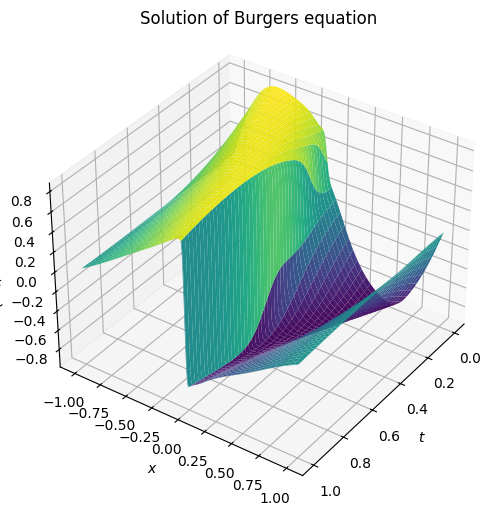

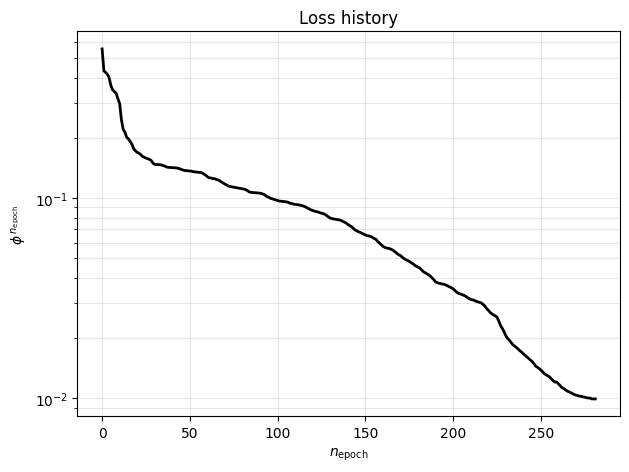

In [16]:
# Plot learned solution
solver.plot_solution()

# Plot training loss history
solver.plot_loss_history()
plt.show()